In [1]:
# Training name
training_name = 'SlimConv2D_SQ_0e_2bit'

# Gaussian noise parameters
NOISE_MU = 0.0
NOISE_SIGMA = 0.0 # e-

# Precision of input data
N_BITS = 2

In [2]:
# IMPORTS ---------------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import os, subprocess
from pathlib import Path
import random

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

from models import *
from plotting import *

2026-07-07 23:40:22.006382: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_centeredIncidence_parquets", 'test_contained/')
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val",'3sr_16x16_'+str(int(NOISE_SIGMA))+'eN_raw_slim')

In [4]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}
thresholds = {}
best_epoch = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i in range(len(fingerprints)):

    base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue
        
    checkpoint_dir = base_dir + 'checkpoints/'
    checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
    checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
    best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]
    os.system('cp '+best_checkpoint+' ' +base_dir)

    best_epoch[i] = int(best_checkpoint.split('weights.')[1].split('-t')[0])

    model = CreateSQModel_Conv2DSlim(shape = (16,16,2), 
                          n_filters=5,
                          pool_size=3)

    print(f"Loading model from {best_checkpoint}")
    model.load_weights(best_checkpoint)

    val_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_val,
        shuffle=True,
        seed=int(seeds[i]),
        quantize=False,
    )

    sf = val_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotB'] = sf[2]

    df = construct_df_slim(model, val_generator, scale_factor)
    df.to_parquet(base_dir+"residuals.parquet")
    residuals[i] = df

    thr = pd.read_csv(base_dir+'soft_quantizer_state_log.csv',header=0,index_col=0,usecols=['epoch'] + ['threshold_'+str(i) for i in range(0,3)])
    thresholds[i] = thr


Seeds =  ['66', '715', '864', '942', '777']
Fingerprints =  ['13e3145d', '4941259f', 'bca934b3', 'cafe06e9', 'fdb7a94d']


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-13e3145d-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.2039-t41.72-v35.08.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eN_raw_slim/metadata.json
21/21 [==============================] - 2s 88ms/step


100%|██████████| 21/21 [00:01<00:00, 15.81it/s]


0.20180395 -0.60974187 1.0162302
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-4941259f-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.1116-t45.84-v37.28.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eN_raw_slim/metadata.json


21/21 [==============================] - 2s 73ms/step


...

100%|██████████| 21/21 [00:01<00:00, 17.53it/s]


0.20180395 -0.60974187 1.0162302


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-fdb7a94d-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.1200-t43.63-v37.81.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_0eN_raw_slim/metadata.json
21/21 [==============================] - 2s 66ms/step


100%|██████████| 21/21 [00:01<00:00, 17.29it/s]


0.20180395 -0.60974187 1.0162302


2039
1116
554
2209
1200


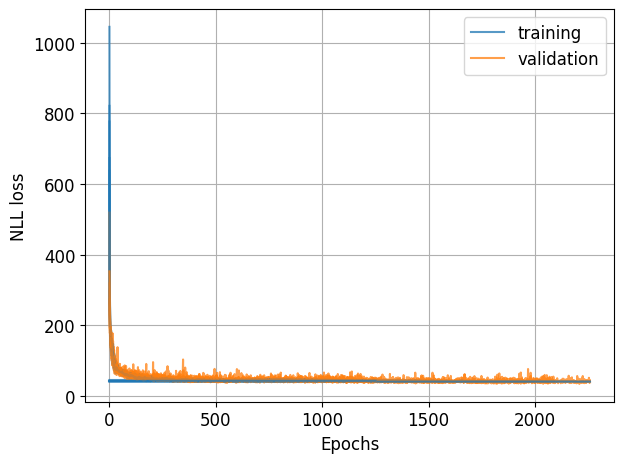

In [5]:
for i in range(len(fingerprints)):

    base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue

    training_cp_path = os.path.join(base_dir, 'training_log.csv')
    training_history = pd.read_csv(training_cp_path)

    print(best_epoch[i])

    plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['loss'][:best_epoch[i]+50], linestyle='-', color=colors[0], alpha=0.75)
    plt.plot(training_history['epoch'][:best_epoch[i]+50], training_history['val_loss'][:best_epoch[i]+50], linestyle='-', color=colors[1], alpha=0.75)
    plt.plot(training_history['epoch'][:best_epoch[i]+50], (best_epoch[i]+50)*[training_history['loss'][best_epoch[i]]], linestyle='-', color=colors[0], alpha=0.75)
    
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

0
1
2
3
4


(0.5, 1000000)

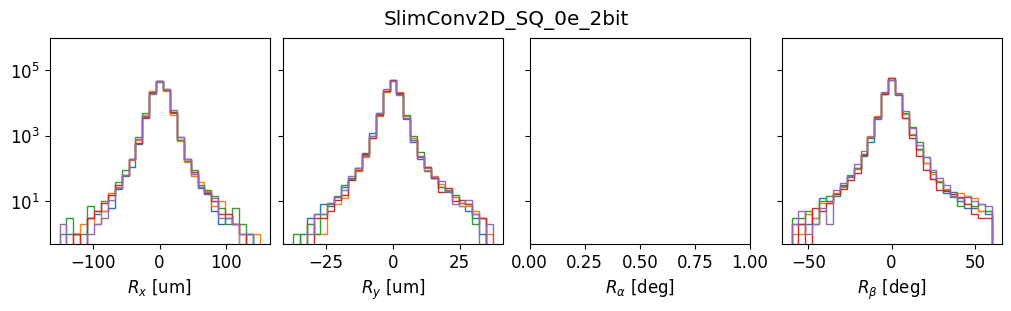

In [6]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for i,df in residuals.items():

    print(i)

    # x
    ax[0].set_xlabel(r'$R_x$ [um]')
    ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[0].set_yscale('log')

    # y
    ax[1].set_xlabel(r'$R_y$ [um]')
    ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[2].set_xlabel(r'$R_\alpha$ [deg]')
    #ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[3].set_xlabel(r'$R_\beta$ [deg]')
    ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
    # Residuals for x and y (microns)
    for v in ['x','y','B','cotB']:
        # Mean
        avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
        # Std -- replace with smallest window containing 68%
        avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

        interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
        avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
        avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

avg_residuals.to_parquet("avg_res_"+training_name+".parquet")

plt.suptitle(training_name);
ax[0].set_ylim(0.5,1000000)
    
#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')

0
1
2
3
4


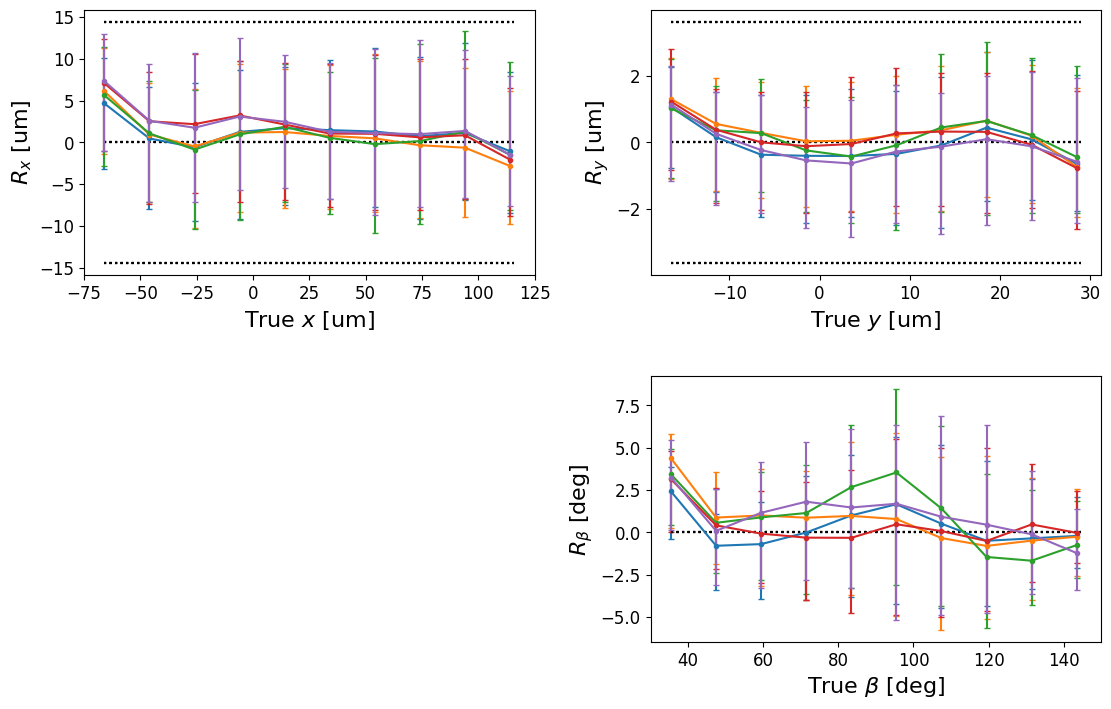

In [7]:
fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

axes[1,0].axis('off')

lines = []
dump = []

for i,df in residuals.items():

    print(i)
    
    lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims=[-75,125])
    dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims=[-25+6.25,25+6.25])
    dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[30,150])


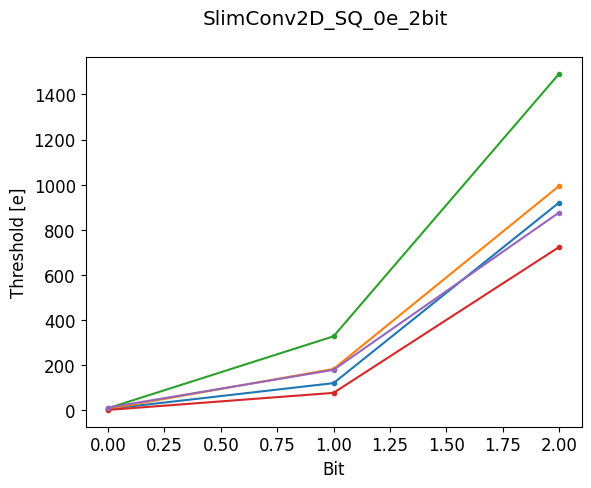

In [8]:
# OVERLAY THRESHOLDS OF ALL TRAININGS --------------------------------------

for i,df in thresholds.items():

    thr = np.array(df.iloc[best_epoch[i]].values)
    plt.plot(np.array(range(np.power(2,N_BITS)-1)), thr, linestyle='-',marker='.',label=str(i))
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

plt.suptitle(training_name);

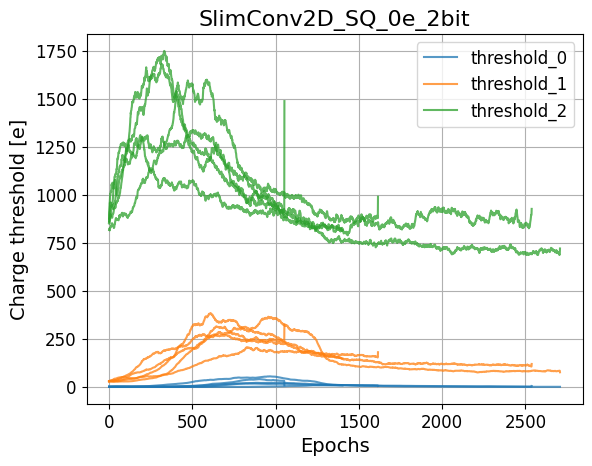

In [9]:
# THRESHOLD EVOLUTION --------------------------------------

plt.grid()


for i,df in thresholds.items():

    for i,c in enumerate(df.columns):
        epochs = df.index
        th_charge = df['threshold_'+str(i)]
        plt.plot(epochs, th_charge, linestyle='-', color=colors[i], alpha=0.75)


plt.legend([f'threshold_{i}' for i in range(3)],bbox_to_anchor=[1,1])
plt.xlabel('Epochs', fontsize =14)
plt.ylabel('Charge threshold [e]', fontsize = 14)
plt.title(training_name, fontsize = 16);


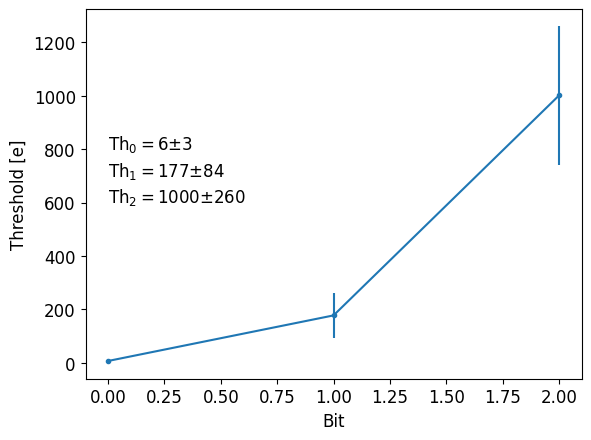

In [10]:
# AVERAGE THRESHOLDS --------------------------------------

th0 = [thresholds[i].iloc[best_epoch[i]][0] for i in range(len(best_epoch))]
th1 = [thresholds[i].iloc[best_epoch[i]][1] for i in range(len(best_epoch))]
th2 = [thresholds[i].iloc[best_epoch[i]][2] for i in range(len(best_epoch))]

th0_mean = np.mean(th0)
th0_sigma = np.std(th0)

th1_mean = np.mean(th1)
th1_sigma = np.std(th1)

th2_mean = np.mean(th2)
th2_sigma = np.std(th2)

plt.errorbar(x=np.array(range(np.power(2,N_BITS)-1)), y=[th0_mean,th1_mean,th2_mean], yerr=[th0_sigma,th1_sigma,th2_sigma], 
             linestyle='-',marker='.',label=training_name)
    
plt.xlabel('Bit')
plt.ylabel('Threshold [e]')

plt.text(0,800,r"Th$_0=$"+str(int(th0_mean))+"$\pm$"+str(int(th0_sigma)))
plt.text(0,700,r"Th$_1=$"+str(int(th1_mean))+"$\pm$"+str(int(th1_sigma)))
plt.text(0,600,r"Th$_2=$"+str(int(th2_mean))+"$\pm$"+str(int(th2_sigma)))

data = np.array([[th0_mean,th0_sigma],[th1_mean,th1_sigma],[th2_mean,th2_sigma]])
df = pd.DataFrame(data,columns=['mean','sigma'])

df.to_parquet("avg_thr_"+training_name+".parquet")

In [11]:
# EVALUATE ON DATASET 2S

In [12]:
# DATA ---------------------------------------------------------------------

dataset_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/"
tfrecords_base_dir = "/uscms/home/jennetd/nobackup/smart-pixels/tfrecords"

dataset_dir_test = os.path.join(dataset_base_dir, "dataset_2s_16x16_50x12P5_centeredIncidence_parquets")
tfrecords_dir_test   = os.path.join(tfrecords_base_dir, "TFR_test",'2s_16x16_'+str(int(NOISE_SIGMA))+'eN_raw_slim')

In [13]:
seeds = grep('Seed','log_'+training_name+'.txt')
print("Seeds = ", seeds)

fingerprints = grep('Fingerprint','log_'+training_name+'.txt')
print("Fingerprints = ", fingerprints)
    
residuals = {}

# BEGIN LOOP ---------------------------------------------------------------------
for i in range(len(fingerprints)):

    base_dir = '/uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-'+fingerprints[i]+'-'+training_name+'-checkpoints/'
    
    if not os.path.exists(base_dir):
        print("Fingerprint " + fingerprints[i] + " not found")
        continue
        
    checkpoint_dir = base_dir + 'checkpoints/'
    checkpoint_files = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if f.endswith('.hdf5')]
    #latest_checkpoint = max(checkpoint_files, key=os.path.getmtime)
    
    checkpoint_val_loss = [float(f.split('-v')[1].split('.hdf5')[0]) for f in checkpoint_files]                      
    best_checkpoint = checkpoint_files[np.argmin(checkpoint_val_loss)]

    model = CreateSQModel_Conv2DSlim(shape = (16,16,2), 
                          n_filters=5,
                          pool_size=3)

    print(f"Loading model from {best_checkpoint}")
    model.load_weights(best_checkpoint)

    test_generator = OptimizedDataGenerator(
        load_from_tfrecords_dir= tfrecords_dir_test,
        shuffle=True,
        seed=int(seeds[i]),
        quantize=False,
    )

    sf = test_generator.labels_scale

    scale_factor = {}
    scale_factor['x'] = sf[0]
    scale_factor['y'] = sf[1]
    scale_factor['cotB'] = sf[2]

    df = construct_df_slim(model, test_generator, scale_factor, is2s = True)
    df.to_parquet(base_dir+"residuals.parquet")
    residuals[i] = df


Seeds =  ['66', '715', '864', '942', '777']
Fingerprints =  ['13e3145d', '4941259f', 'bca934b3', 'cafe06e9', 'fdb7a94d']
Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-13e3145d-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.2039-t41.72-v35.08.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_0eN_raw_slim/metadata.json


278/278 [==============================] - 23s 82ms/step


100%|██████████| 278/278 [00:15<00:00, 17.62it/s]


0.20339514 -0.6087434 1.0145767


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-4941259f-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.1116-t45.84-v37.28.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_0eN_raw_slim/metadata.json
278/278 [==============================] - 17s 61ms/step


...

100%|██████████| 278/278 [00:20<00:00, 13.77it/s]


0.20339514 -0.6087434 1.0145767


Loading model from /uscms/home/jennetd/nobackup/smart-pixels/noise-paper/trained_models/model-fdb7a94d-SlimConv2D_SQ_0e_2bit-checkpoints/checkpoints/weights.1200-t43.63-v37.81.hdf5
Loading metadata from /uscms/home/jennetd/nobackup/smart-pixels/tfrecords/TFR_test/2s_16x16_0eN_raw_slim/metadata.json
278/278 [==============================] - 24s 84ms/step


100%|██████████| 278/278 [00:23<00:00, 12.00it/s]


0.20339514 -0.6087434 1.0145767


0
1
2
3
4


(0.5, 10000000)

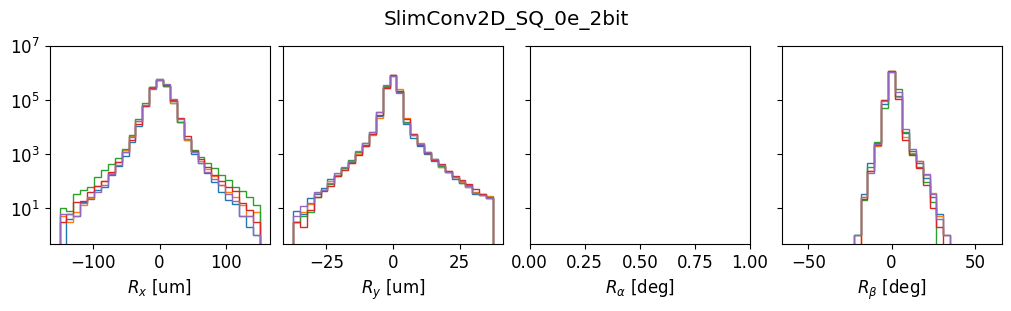

In [14]:
# OVERLAY RESIDUALS OF ALL TRAININGS --------------------------------------

# Pixel pitch (um)
xpitch = 50
ypitch = 12.5
# Thickness (um)
D = 100
# Size of pixel array
lenx = 16
leny = 16

cols = []
for v in ['x','y','A','B','cotA','cotB']:
    cols = cols + ['mean_'+v, 'std_'+v, 'up68_'+v, 'down68_'+v]
avg_residuals = pd.DataFrame(None, index=np.arange(len(fingerprints)),columns=cols)

fig, ax = plt.subplots(1,4,figsize=(10,3),sharey='row', constrained_layout=True)

for i,df in residuals.items():

    print(i)

    # x
    ax[0].set_xlabel(r'$R_x$ [um]')
    ax[0].hist(df["residualx"],histtype='step',bins=np.linspace(-3*xpitch,3*xpitch,30),color=colors[i])
    ax[0].set_yscale('log')

    # y
    ax[1].set_xlabel(r'$R_y$ [um]')
    ax[1].hist(df["residualy"],histtype='step',bins=np.linspace(-3*ypitch,3*ypitch,30),color=colors[i])

    # alpha
    ax[2].set_xlabel(r'$R_\alpha$ [deg]')
    #ax[2].hist(df["residualA"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
    
    # beta
    ax[3].set_xlabel(r'$R_\beta$ [deg]')
    ax[3].hist(df["residualB"],histtype='step',bins=np.linspace(-60,60,30),color=colors[i])
      
    # Residuals for x and y (microns)
    for v in ['x','y','B','cotB']:
        # Mean
        avg_residuals['mean_'+v].iloc[i] = float(np.mean(df['residual'+v]))
        # Std -- replace with smallest window containing 68%
        avg_residuals['std_'+v].iloc[i] = float(np.std(df['residual'+v]))

        interval68 = shortest_interval_68(df['residual'+v], center_type='mean')
        avg_residuals['up68_'+v].iloc[i] = interval68['error_high']
        avg_residuals['down68_'+v].iloc[i] = interval68['error_low']

avg_residuals.to_parquet("avg_res_2s_"+training_name+".parquet")

plt.suptitle(training_name);
ax[0].set_ylim(0.5,10000000)
    
#plt.tight_layout()
#plt.savefig('plots/'+training_name+'_residuals.png')

0
1
2
3
4


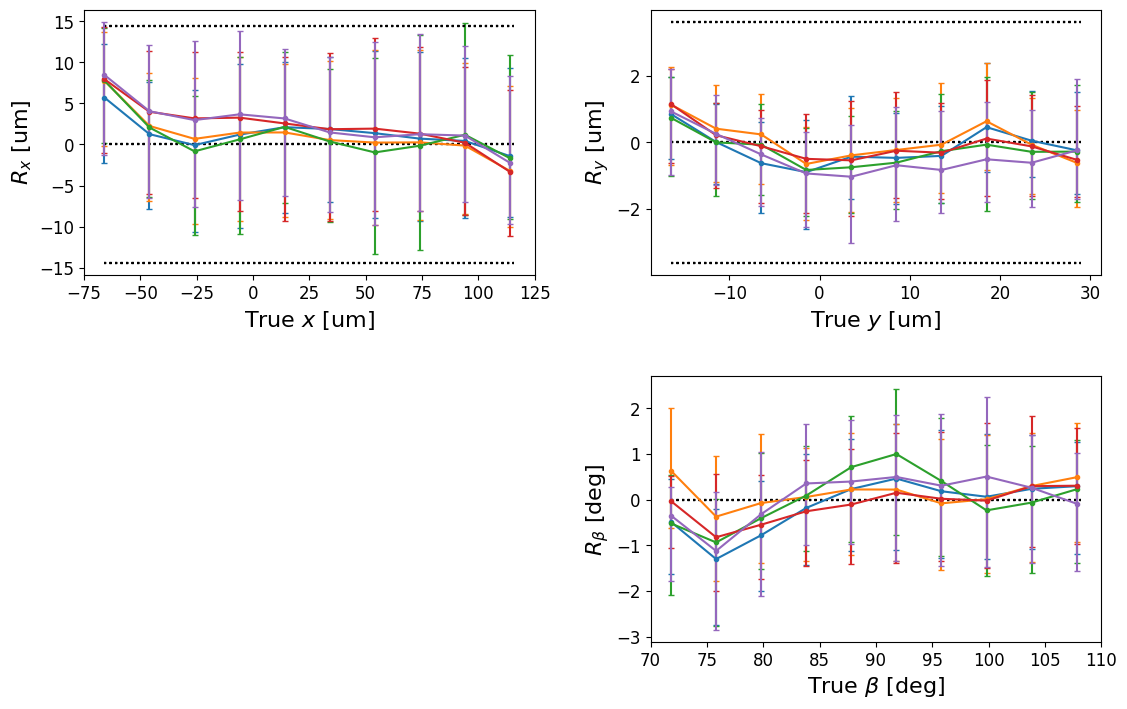

In [15]:
fig, axes = plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
fig.tight_layout(pad=4.0)

axes[1,0].axis('off')

lines = []
dump = []

for i,df in residuals.items():

    print(i)

    vbl_names = {'x':r'$R_x$ [um]', 'y':r'$R_y$ [um]', 'A':r'$R_\alpha$ [deg]', 'B':r'$R_\beta$ [deg]'}
    
    lines += residual_plot_slim(axes[0][0],df,'xtrue','x',r'$x$ [um]',lims=[-75,125])
    dump += residual_plot_slim(axes[0][1],df,'ytrue','y',r'$y$ [um]',lims=[-25+6.25,25+6.25])
    dump += residual_plot_slim(axes[1][1],df,'Btrue','B',r'$\beta$ [deg]',lims=[70,110])
